# Notebook 2 — versión simultánea actualizada

Este notebook usa como entrada la exportación de `Notebook 1` (`S/lb/ub/ids` y, opcionalmente, `dfba_vargam_metadata.jl`) para construir una **versión simultánea** del problema en Julia.

Decisiones metodológicas incorporadas:
- **S fija**
- **GAM variable inyectada como carga exógena sobre ATPM** (`GAM_EXTRA_FE`)
- **turnover, pools AA y aromas endógenos**
- **switch suave BIOMASS → TURNOVER_ATPM**
- **pairwise ester coupling + ethyl acetate soft coupling**
- **relajación del pFBA secundario** mediante incentivo leve + regularización

In [1]:
using JuMP
using Ipopt
using LinearAlgebra
using DelimitedFiles
using Printf
using Statistics
using Plots

HAS_DATAFRAMES = true
try
    using DataFrames
catch
    HAS_DATAFRAMES = false
end

include("pFBA_KKT_flux_Zenteno_vargam_simultaneous.jl")

OUT_DIR   = get(ENV, "OUT_DIR", joinpath(pwd(), "out"))
S_FILE    = joinpath(OUT_DIR, "S.csv")
LB_FILE   = joinpath(OUT_DIR, "lb.csv")
UB_FILE   = joinpath(OUT_DIR, "ub.csv")
RXN_FILE  = joinpath(OUT_DIR, "rxn_ids.txt")
MET_FILE  = joinpath(OUT_DIR, "met_ids.txt")
META_FILE = joinpath(OUT_DIR, "dfba_vargam_metadata.jl")

XK_FILE   = joinpath(OUT_DIR, "xk_simultaneous.csv")
TS_FILE   = joinpath(OUT_DIR, "t_simultaneous.csv")
V_FILE    = joinpath(OUT_DIR, "v_simultaneous.csv")
FIG_FILE  = joinpath(OUT_DIR, "dfba_simultaneous.png")

for f in (S_FILE, LB_FILE, UB_FILE, RXN_FILE, MET_FILE)
    @assert isfile(f) "Falta archivo requerido: $(f). Ejecuta Notebook 1 primero."
end

println("OUT_DIR = ", OUT_DIR)
println("META    = ", isfile(META_FILE) ? META_FILE : "no encontrado (se usarán defaults)")

OUT_DIR = c:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out
META    = c:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out\dfba_vargam_metadata.jl


In [2]:
S = Float64.(readdlm(S_FILE, ','))
lbraw = readdlm(LB_FILE, ',')
ubraw = readdlm(UB_FILE, ',')
RXN_IDS = readlines(RXN_FILE)
MET_IDS = readlines(MET_FILE)

vlb = lbraw isa AbstractVector ? Float64.(lbraw) : Float64.(lbraw[:, 1])
vub = ubraw isa AbstractVector ? Float64.(ubraw) : Float64.(ubraw[:, 1])

nm = size(S, 1)
nv = size(S, 2)

RXN_INDEX = Dict{String, Int}(rid => i for (i, rid) in enumerate(RXN_IDS))
MET_INDEX = Dict{String, Int}(mid => i for (i, mid) in enumerate(MET_IDS))

META = Dict{String,Any}()
if isfile(META_FILE)
    include(META_FILE)
    if @isdefined DFBA_META
        META = deepcopy(DFBA_META)
    end
end

function _meta_get(meta::Dict{String,Any}, key::String, default)
    haskey(meta, key) ? meta[key] : default
end

function _dict_string_string(x)
    d = Dict{String,String}()
    for (k,v) in pairs(x)
        d[string(k)] = string(v)
    end
    return d
end

function _dict_string_float(x)
    d = Dict{String,Float64}()
    for (k,v) in pairs(x)
        d[string(k)] = Float64(v)
    end
    return d
end

OBJ_ID  = _meta_get(META, "obj_id", "r_2111")
GLU_ID  = _meta_get(META, "glu_id", "r_1714")
FRU_ID  = _meta_get(META, "fru_id", "r_1709")
ETH_ID  = _meta_get(META, "eth_id", "r_1761")
O2_ID   = _meta_get(META, "o2_id",  "r_1992")
ATPM_ID = _meta_get(META, "atpm_id","r_4046")
PROT_RXN_ID = _meta_get(META, "prot_rxn_id", "r_4047")

for rid in [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID, ATPM_ID, PROT_RXN_ID]
    @assert haskey(RXN_INDEX, rid) "Falta reacción requerida: $(rid)"
end

obj = RXN_INDEX[OBJ_ID]
glu = RXN_INDEX[GLU_ID]
fru = RXN_INDEX[FRU_ID]
eth = RXN_INDEX[ETH_ID]
o2  = RXN_INDEX[O2_ID]
IDX_ATPM = RXN_INDEX[ATPM_ID]
IDX_PROT_RXN = RXN_INDEX[PROT_RXN_ID]

kinetic_n_default = ["r_1654", "r_1879", "r_1891", "r_1889", "r_1906", "r_1911", "r_1873", "r_1912"]
KINETIC_N_SOURCE_IDS = [string(x) for x in _meta_get(META, "kinetic_n_source_ids", kinetic_n_default)]
for rid in KINETIC_N_SOURCE_IDS
    @assert haskey(RXN_INDEX, rid) "Falta fuente cinética de N: $(rid)"
end
KINETIC_N_SOURCE_IDXS = [RXN_INDEX[rid] for rid in KINETIC_N_SOURCE_IDS]

AA_EXCHANGE_MAP = haskey(META, "aa_exchange_ids") ? _dict_string_string(META["aa_exchange_ids"]) :
    Dict("phe"=>"r_1898", "leu"=>"r_1890", "val"=>"r_1910", "met"=>"r_1893", "tyr"=>"r_1914")
for rid in values(AA_EXCHANGE_MAP)
    @assert haskey(RXN_INDEX, rid) "Falta exchange de AA: $(rid)"
end

AROMA_EXCHANGE_MAP = haskey(META, "aroma_exchange_ids") ? _dict_string_string(META["aroma_exchange_ids"]) :
    Dict("pea"=>"r_1590", "isoamyl"=>"r_1865", "isobutanol"=>"r_1866", "methionol"=>"r_1900", "tyrosol"=>"r_1915")
for rid in values(AROMA_EXCHANGE_MAP)
    @assert haskey(RXN_INDEX, rid) "Falta exchange de aroma/alcohol: $(rid)"
end

AA_KEYS = collect(keys(AA_EXCHANGE_MAP))
AROMA_KEYS = collect(keys(AROMA_EXCHANGE_MAP))
sort!(AA_KEYS)
sort!(AROMA_KEYS)

AA_UPTAKE_IDXS = [RXN_INDEX[AA_EXCHANGE_MAP[k]] for k in AA_KEYS]
AROMA_RXN_IDXS = [RXN_INDEX[AROMA_EXCHANGE_MAP[k]] for k in AROMA_KEYS]

UPTAKE_IDXS = vcat([glu, fru], KINETIC_N_SOURCE_IDXS)
PRODUCT_IDXS = [eth, obj]
n_up = length(UPTAKE_IDXS)
n_prod = length(PRODUCT_IDXS)

IS_GLU = [idx == glu ? 1.0 : 0.0 for idx in UPTAKE_IDXS]
IS_FRU = [idx == fru ? 1.0 : 0.0 for idx in UPTAKE_IDXS]
IS_NIT = [1.0 - IS_GLU[i] - IS_FRU[i] for i in eachindex(UPTAKE_IDXS)]

SELECT_UPTAKE = [Float64(mc == UPTAKE_IDXS[k]) for mc in 1:nv, k in 1:n_up]
SELECT_PRODUCT = [Float64(mc == PRODUCT_IDXS[k]) for mc in 1:nv, k in 1:n_prod]

IS_ETH_prod = [1.0, 0.0]
IS_OBJ_prod = [0.0, 1.0]

N_atoms_map = haskey(META, "n_atoms_map") ? _dict_string_float(META["n_atoms_map"]) : Dict{String,Float64}()
N_frac_map  = haskey(META, "n_frac_map")  ? _dict_string_float(META["n_frac_map"])  : Dict{String,Float64}()

MW_N   = 0.014007
MW_GLU = 0.180156
MW_FRU = 0.180156
MW_ETH = 0.046070
MW_O2  = 0.031998

N_atoms_vec = ones(nv)
N_profile_vec = zeros(nv)
for (rid, val) in pairs(N_atoms_map)
    haskey(RXN_INDEX, rid) && (N_atoms_vec[RXN_INDEX[rid]] = Float64(val))
end
for (rid, val) in pairs(N_frac_map)
    haskey(RXN_INDEX, rid) && (N_profile_vec[RXN_INDEX[rid]] = Float64(val))
end

N_frac = zeros(n_up)
for k in 1:n_up
    idx = UPTAKE_IDXS[k]
    if IS_NIT[k] > 0.5
        N_frac[k] = N_profile_vec[idx] / max(N_atoms_vec[idx] * MW_N, 1e-12)
    end
end

AA_ALPHA_MAP = haskey(META, "aa_alpha") ? _dict_string_float(META["aa_alpha"]) :
    Dict(k => 1.0 / max(length(AA_KEYS), 1) for k in AA_KEYS)
AA_ALPHA_VEC = [get(AA_ALPHA_MAP, k, 0.0) for k in AA_KEYS]

AA_MW_MAP = haskey(META, "aa_mw") ? _dict_string_float(META["aa_mw"]) :
    Dict("phe"=>0.16519, "leu"=>0.13117, "val"=>0.11715, "met"=>0.14921, "tyr"=>0.18119)
AROMA_MW_MAP = haskey(META, "aroma_mw") ? _dict_string_float(META["aroma_mw"]) :
    Dict("pea"=>0.12217, "isoamyl"=>0.08815, "isobutanol"=>0.07412, "methionol"=>0.10619, "tyrosol"=>0.13816)
AROMA_MW_VEC = [get(AROMA_MW_MAP, k, 0.1) for k in AROMA_KEYS]

# Pairwise / ethyl acetate defaults aligned with Notebook 1
pairwise_default = [
    ("r_1862", "r_1865", 0.08),
    ("r_1867", "r_1866", 0.08),
    ("r_2000", "r_1589", 0.08),
]
PAIRWISE_META = haskey(META, "pairwise_constraints") ? META["pairwise_constraints"] : pairwise_default
PAIRWISE_ESTER_IDXS = Int[]
PAIRWISE_ALCOHOL_IDXS = Int[]
PAIRWISE_PHI = Float64[]
for row in PAIRWISE_META
    ester_rid = string(row[1])
    alcohol_rid = string(row[2])
    phi = Float64(row[3])
    if haskey(RXN_INDEX, ester_rid) && haskey(RXN_INDEX, alcohol_rid)
        push!(PAIRWISE_ESTER_IDXS, RXN_INDEX[ester_rid])
        push!(PAIRWISE_ALCOHOL_IDXS, RXN_INDEX[alcohol_rid])
        push!(PAIRWISE_PHI, phi)
    end
end
@assert !isempty(PAIRWISE_ESTER_IDXS) "No se detectaron pares ester↔alcohol."

PAIR_ALCOHOL_SELECT = [Float64(mc == PAIRWISE_ALCOHOL_IDXS[p]) for mc in 1:nv, p in 1:length(PAIRWISE_PHI)]
PAIR_ESTER_SELECT   = [Float64(mc == PAIRWISE_ESTER_IDXS[p])   for mc in 1:nv, p in 1:length(PAIRWISE_PHI)]

EA_SOFT_ESTER_IDX = 0
EA_SOFT_ALCOHOL_IDX = 0
PHI_ETHYL_ACETATE_STATIC = 0.0
if haskey(META, "ethyl_acetate_soft")
    ea = META["ethyl_acetate_soft"]
    ester_rid = string(ea["ester_rid"])
    alcohol_rid = string(ea["alcohol_rid"])
    if haskey(RXN_INDEX, ester_rid) && haskey(RXN_INDEX, alcohol_rid)
        EA_SOFT_ESTER_IDX = RXN_INDEX[ester_rid]
        EA_SOFT_ALCOHOL_IDX = RXN_INDEX[alcohol_rid]
        PHI_ETHYL_ACETATE_STATIC = Float64(ea["phi"])
    end
else
    if haskey(RXN_INDEX, "r_1765") && haskey(RXN_INDEX, ETH_ID)
        EA_SOFT_ESTER_IDX = RXN_INDEX["r_1765"]
        EA_SOFT_ALCOHOL_IDX = RXN_INDEX[ETH_ID]
        PHI_ETHYL_ACETATE_STATIC = 0.005
    end
end

EA_ALCOHOL_SELECT = [Float64(mc == EA_SOFT_ALCOHOL_IDX) for mc in 1:nv]
EA_ESTER_SELECT   = [Float64(mc == EA_SOFT_ESTER_IDX) for mc in 1:nv]
OBJ_SELECT  = [Float64(mc == obj) for mc in 1:nv]
ATPM_SELECT = [Float64(mc == IDX_ATPM) for mc in 1:nv]

println("nm=$(nm), nv=$(nv), nAA=$(length(AA_KEYS)), nAroma=$(length(AROMA_KEYS)), nPair=$(length(PAIRWISE_PHI))")

nm=2806, nv=4131, nAA=5, nAroma=5, nPair=3


In [3]:
# -----------------------------
# Parámetros cinéticos / composición
# -----------------------------
MU0_nom    = 0.141665
YXN_nom    = 9.80576
YXG_nom    = 0.394345
YXF_nom    = 0.18622
YEG_nom    = 0.14133
YEF_nom    = 0.96932
Kn0_nom    = 0.226882
Kg0_nom    = 3.1514
Kf0_nom    = 2.97625
Kig0_nom   = 29.5276
Kie0_nom   = 2.99809
Kd0_nom    = 3.11736e-5
betaG0_nom = 1.41182
betaF0_nom = 8.49482
MRATE_0    = 0.01

MU0 = MU0_nom
YEG = YEG_nom
YEF = YEF_nom
YXN = YXN_nom
R = 8.314
EPS = 1e-9

PROT_CONTENT_0 = Float64(_meta_get(META, "PROT_CONTENT_0", 0.46))
CARB_CONTENT_0 = Float64(_meta_get(META, "CARB_CONTENT_0", 0.37))
RNA_FRAC       = Float64(_meta_get(META, "RNA_FRAC", 0.06))
K_DEATH        = Float64(_meta_get(META, "K_DEATH", 0.005))
TURNOVER_LAMBDA = Float64(_meta_get(META, "TURNOVER_LAMBDA", 0.03))
XA_FRACTION     = Float64(_meta_get(META, "XA_FRACTION", 1.0))
N_AMMONIA_FRACTION = Float64(_meta_get(META, "N_AMMONIA_FRACTION", 0.50))
N_TOTAL_DEPLETION_THRESHOLD = Float64(_meta_get(META, "N_TOTAL_DEPLETION_THRESHOLD", 1e-3))
K_AA_UPTAKE_GROWTH = Float64(_meta_get(META, "K_AA_UPTAKE_GROWTH", 0.08))

ATPM_LB_NO_GROWTH = Float64(_meta_get(META, "ATPM_LB_NO_GROWTH", 0.70))
ATPM_UB_NO_GROWTH = Float64(_meta_get(META, "ATPM_UB_NO_GROWTH", 1000.0))

GAM_BASE = Float64(_meta_get(META, "GAM_BASE", 24.7))
GAM_COEFF_P = Float64(_meta_get(META, "GAM_COEFF_P", 16.965))
GAM_COEFF_R = Float64(_meta_get(META, "GAM_COEFF_R", 1.638))
GAM_COEFF_C = Float64(_meta_get(META, "GAM_COEFF_C", 5.210))
Pbase_global = Float64(_meta_get(META, "Pbase_global", PROT_CONTENT_0))
Cbase_global = Float64(_meta_get(META, "Cbase_global", CARB_CONTENT_0))
Rbase_global = Float64(_meta_get(META, "Rbase_global", RNA_FRAC))

function compute_full_gam(P, Rna, Carb, Pbase, Rbase, Cbase)
    Pfactor = P / max(Pbase, 1e-9)
    Rfactor = Rna / max(Rbase, 1e-9)
    Cfactor = max(0.0, (Cbase + Pbase - P - Rna) / max(Cbase, 1e-9))
    return GAM_BASE + GAM_COEFF_P * Pfactor + GAM_COEFF_R * Rfactor + GAM_COEFF_C * Cfactor
end

GAM_REF = compute_full_gam(PROT_CONTENT_0, RNA_FRAC, CARB_CONTENT_0, Pbase_global, Rbase_global, Cbase_global)

# -----------------------------
# Perfil térmico e inyección
# -----------------------------
T_BASE  = try parse(Float64, get(ENV, "T_CONST", "293.15")) catch; 293.15 end
T_STEPS = [36.0, 96.0]
T_DELTAS = [5.0, 3.0]
T_STEEP = 0.5

function dynamic_temperature(t)
    val = T_BASE
    for i in eachindex(T_STEPS)
        σ = 1.0 / (1.0 + exp(-T_STEEP * (t - T_STEPS[i])))
        val += T_DELTAS[i] * σ
    end
    return val
end

function death_rate_T(E, T_val)
    Td = -0.0001 * E^3 + 0.0049 * E^2 - 0.1279 * E + 315.89
    s = 0.5 * (1.0 + tanh(0.5 * (T_val - Td)))
    base = Kd0_nom * exp(0.0415 * E + (130000.0 * (T_val - 305.65)) / (305.65 * R * T_val))
    return base * s
end

SQRT_2PI = sqrt(2.0 * pi)
function smooth_injection(t, t_shot, dose, width)
    abs(t - t_shot) > 5 * width && return 0.0
    return (dose / (width * SQRT_2PI)) * exp(-0.5 * ((t - t_shot) / width)^2)
end

T_INJ_1 = 0.0; DOSE_1 = 0.0; WIDTH_1 = 5.0
T_INJ_2 = 0.0; DOSE_2 = 0.0; WIDTH_2 = 5.0

5.0

In [4]:
# -----------------------------
# Malla, estados y escalas
# -----------------------------
nfe = try parse(Int, get(ENV, "NFE", "6")) catch; 18 end
ncp = 3
th  = try parse(Float64, get(ENV, "TH", "72.0")) catch; 168.0 end
h   = th / nfe
hm  = fill(h, nfe)
var_h = 0.50

IDX_X     = 1
IDX_NFREE = 2
IDX_G     = 3
IDX_F     = 4
IDX_E     = 5
IDX_O2    = 6
IDX_PROT  = 7
IDX_CARB  = 8

AA_STATE_IDXS = collect(9:(8 + length(AA_KEYS)))
AROMA_STATE_IDXS = collect((9 + length(AA_KEYS)):(8 + length(AA_KEYS) + length(AROMA_KEYS)))

nc = 8 + length(AA_KEYS) + length(AROMA_KEYS)

X0 = 0.5
N0_total = 0.14
N0_ammonia = N0_total * N_AMMONIA_FRACTION
N0_from_aa = max(0.0, N0_total - N0_ammonia)
AA0_each = (N0_from_aa / MW_N) / max(length(AA_KEYS), 1)

c0 = zeros(nc)
c0[IDX_X] = X0
c0[IDX_NFREE] = N0_ammonia
c0[IDX_G] = 110.0
c0[IDX_F] = 110.0
c0[IDX_E] = 0.0
c0[IDX_O2] = 0.0
c0[IDX_PROT] = X0 * PROT_CONTENT_0
c0[IDX_CARB] = X0 * CARB_CONTENT_0
for a in eachindex(AA_STATE_IDXS)
    c0[AA_STATE_IDXS[a]] = AA0_each
end
for a in eachindex(AROMA_STATE_IDXS)
    c0[AROMA_STATE_IDXS[a]] = 0.0
end

cs = ones(nc)
cs[IDX_NFREE] = 0.2
cs[IDX_G] = 100.0
cs[IDX_F] = 100.0
cs[IDX_E] = 10.0
cs[IDX_O2] = 0.01
cs[IDX_PROT] = max(0.1, c0[IDX_PROT])
cs[IDX_CARB] = max(0.1, c0[IDX_CARB])
for s in AA_STATE_IDXS
    cs[s] = max(0.1, c0[s])
end
for s in AROMA_STATE_IDXS
    cs[s] = 0.01
end

# Escalado de flujos
FLUX_SCALE_TARGET = 50.0
vs = ones(nv)
for rx in 1:nv
    br = max(abs(vlb[rx]), abs(vub[rx]))
    if br > FLUX_SCALE_TARGET
        vs[rx] = br / FLUX_SCALE_TARGET
    end
end

# Selectores para stationarity
SELECT_AAUPTAKE = [Float64(mc == AA_UPTAKE_IDXS[a]) for mc in 1:nv, a in eachindex(AA_UPTAKE_IDXS)]
D_GROWTH = zeros(nv); D_GROWTH[obj] = -1.0
D_TURNOVER = zeros(nv); D_TURNOVER[IDX_ATPM] = -1.0
D_AAUP = zeros(nv)
for idx in AA_UPTAKE_IDXS
    D_AAUP[idx] = 1e-3
end

# Parámetros del NLP / MPCC
IPOPT_LINEAR_SOLVER = lowercase(get(ENV, "IPOPT_LINEAR_SOLVER", "mumps"))
IPOPT_PRINT_LEVEL = try parse(Int, get(ENV, "IPOPT_PRINT_LEVEL", "5")) catch; 5 end
IPOPT_TOL = try parse(Float64, get(ENV, "IPOPT_TOL", "1e-4")) catch; 1e-4 end
IPOPT_ACCEPTABLE_TOL = try parse(Float64, get(ENV, "IPOPT_ACCEPTABLE_TOL", "1e-2")) catch; 1e-2 end
IPOPT_ACCEPTABLE_ITER = try parse(Int, get(ENV, "IPOPT_ACCEPTABLE_ITER", "12")) catch; 12 end
IPOPT_MAX_ITER = try parse(Int, get(ENV, "IPOPT_MAX_ITER", "10")) catch; 500 end
IPOPT_CONSTR_VIOL_TOL = try parse(Float64, get(ENV, "IPOPT_CONSTR_VIOL_TOL", "1e-5")) catch; 1e-5 end
IPOPT_COMPL_INF_TOL = try parse(Float64, get(ENV, "IPOPT_COMPL_INF_TOL", "1e-4")) catch; 1e-4 end

PHI_L = 1.0
PHI_U = 1.0
PHI_UPT = 1.0
PHI_PROD = 1.0
PHI_AA = 1.0
PHI_PAIR = 1.0
PHI_EA = 1.0
PHI_ATPM = 1.0
Q_REG = 1e-8
FLUX_SMOOTH_WEIGHT = 1e-8
SOFTPLUS_V_EPS = 1e-6
PHASE_SMOOTH_EPS = 5e-4

APPLY_PRODUCT_CAPS = lowercase(get(ENV, "APPLY_PRODUCT_CAPS", "false")) in ("1", "true", "yes", "on")
EPS_FLUX = try parse(Float64, get(ENV, "EPS_FLUX", "1e-5")) catch; 1e-5 end

println("nc=$(nc), nfe=$(nfe), ncp=$(ncp), th=$(th), apply_caps=$(APPLY_PRODUCT_CAPS)")
println("IPOPT_MAX_ITER = ", IPOPT_MAX_ITER)
println("NFE = ", nfe)
println("TH = ", th)

nc=18, nfe=6, ncp=3, th=72.0, apply_caps=false
IPOPT_MAX_ITER = 10
NFE = 6
TH = 72.0


In [5]:
# -----------------------------
# GAM exógena desde Notebook 1
# -----------------------------
# Idealmente Notebook 1 exporta baseline_time_h y baseline_gam_mmol_gdw.
# Si no están, se usa carga extra nula.

function _vector_from_meta(meta::Dict{String,Any}, key::String)
    if !haskey(meta, key)
        return Float64[]
    end
    return [Float64(x) for x in meta[key]]
end

baseline_time_h = _vector_from_meta(META, "baseline_time_h")
baseline_gam_mmol_gdw = _vector_from_meta(META, "baseline_gam_mmol_gdw")

function linear_interp(xq::Vector{Float64}, xp::Vector{Float64}, yp::Vector{Float64})
    isempty(xp) && return zeros(length(xq))
    @assert length(xp) == length(yp)
    yq = similar(xq)
    for i in eachindex(xq)
        x = xq[i]
        if x <= xp[1]
            yq[i] = yp[1]
        elseif x >= xp[end]
            yq[i] = yp[end]
        else
            j = searchsortedlast(xp, x)
            x1, x2 = xp[j], xp[j+1]
            y1, y2 = yp[j], yp[j+1]
            θ = (x - x1) / max(x2 - x1, 1e-12)
            yq[i] = y1 + θ * (y2 - y1)
        end
    end
    return yq
end

tfe_preview = cumsum(hm)
if !isempty(baseline_time_h) && !isempty(baseline_gam_mmol_gdw)
    GAM_FE = linear_interp(Float64.(tfe_preview), baseline_time_h, baseline_gam_mmol_gdw)
else
    GAM_FE = fill(GAM_REF, nfe)
end
GAM_EXTRA_FE = max.(0.0, GAM_FE .- GAM_REF)

println(@sprintf("GAM_REF = %.4f", GAM_REF))
println(@sprintf("GAM_FE range = [%.4f, %.4f]", minimum(GAM_FE), maximum(GAM_FE)))
println(@sprintf("GAM_EXTRA_FE range = [%.4f, %.4f]", minimum(GAM_EXTRA_FE), maximum(GAM_EXTRA_FE)))

GAM_REF = 47.6681
GAM_FE range = [47.6681, 47.6681]
GAM_EXTRA_FE range = [0.0000, 0.0000]


In [6]:
println("Resolviendo modelo simultáneo actualizado...")
sol, solv, solcd, soll, solalL, solalU, solau, solap, solaaa, solapr, solaea, solaatpm, solh, diag =
    pFBA_KKT_flux_Zenteno_vargam_simultaneous(
        c0;
        eps_flux = EPS_FLUX,
        apply_product_caps = APPLY_PRODUCT_CAPS,
    )

println("solver.term   = ", diag.solver.term)
println("solver.primal = ", diag.solver.primal)
println("solver.dual   = ", diag.solver.dual)
println(@sprintf("uptake viol   = %.3e", diag.uptake_violation))
println(@sprintf("product viol  = %.3e", diag.product_violation))

Resolviendo modelo simultáneo actualizado...

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...: 70566138
Number of nonzeros in inequality constraint Jacobian.:   133482
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:   141684
                     variables with only lower bounds:    25158
                variables with lower and upper bounds:        0
                     variables with only upper bounds:    24876
Total number of equality constraints...........

In [7]:
# -----------------------------
# Reconstrucción de trayectorias
# -----------------------------
radau_pts = [0.15505102572168, 0.64494897427832, 1.0]

ts = Vector{Float64}(undef, nfe + 1)
ts[1] = 0.0
for i in 2:nfe+1
    ts[i] = ts[i-1] + solh[i-1]
end

n_pts = nfe * ncp + 1
tsn = Vector{Float64}(undef, n_pts)
xk = Matrix{Float64}(undef, nc, n_pts)

tsn[1] = 0.0
xk[:, 1] = c0
for i in 1:nfe
    for j in 1:ncp
        kk = (i - 1) * ncp + j + 1
        xk[:, kk] = sol[:, i, j]
        tsn[kk] = ts[i] + radau_pts[j] * solh[i]
    end
end

writedlm(XK_FILE, xk, ',')
writedlm(TS_FILE, tsn, ',')
writedlm(V_FILE, solv, ',')

println("Guardados:")
println(" - ", XK_FILE)
println(" - ", TS_FILE)
println(" - ", V_FILE)

Guardados:
 - c:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out\xk_simultaneous.csv
 - c:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out\t_simultaneous.csv
 - c:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out\v_simultaneous.csv



RESUMEN DE ESTADOS (endpoint collocation path)
X                inicio=    0.5000  fin=    0.5000  min=    0.5000  max=    0.5000
N_free           inicio=    0.0700  fin=    0.0700  min=    0.0700  max=    0.0700
G                inicio=  110.0000  fin=  110.0000  min=  110.0000  max=  110.0000
F                inicio=  110.0000  fin=  110.0000  min=  110.0000  max=  110.0000
E                inicio=    0.0000  fin=    0.1000  min=    0.0000  max=    0.1000
O2               inicio=    0.0000  fin=    0.0001  min=    0.0000  max=    0.0001
Prot             inicio=    0.2300  fin=    0.2300  min=    0.2300  max=    0.2300
Carb             inicio=    0.1850  fin=    0.1850  min=    0.1850  max=    0.1850
AA_leu           inicio=    0.9995  fin=    0.9995  min=    0.9995  max=    0.9995
AA_met           inicio=    0.9995  fin=    0.9995  min=    0.9995  max=    0.9995
AA_phe           inicio=    0.9995  fin=    0.9995  min=    0.9995  max=    0.9995
AA_tyr           inicio=    0.9995  fin

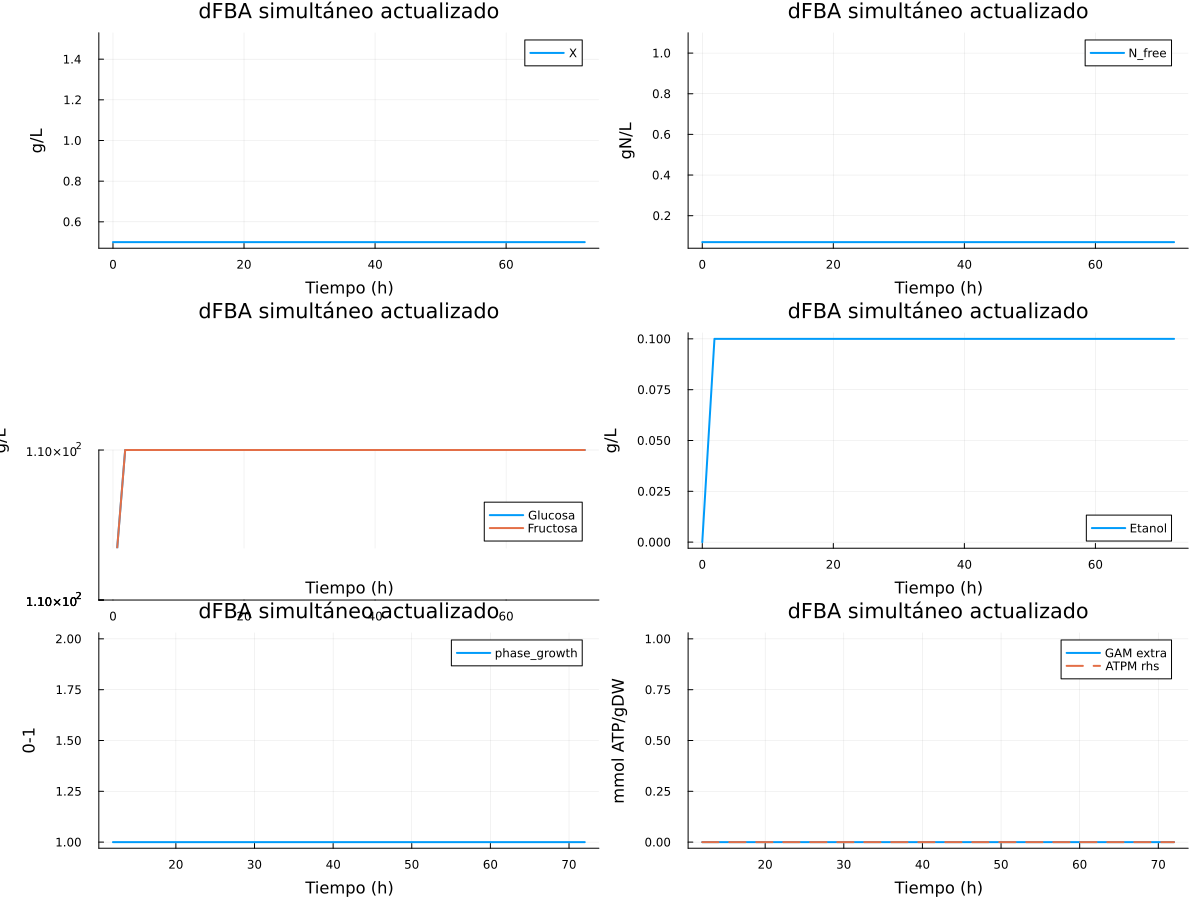

GKS: Possible loss of precision in routine SET_WINDOW


In [8]:
# -----------------------------
# Diagnóstico y gráficos
# -----------------------------
tfe = ts[2:end]

phase_fe = diag.phase_growth
gam_extra_fe = diag.gam_extra
atpm_rhs_fe = diag.atpm_rhs

x_names = ["X", "N_free", "G", "F", "E", "O2", "Prot", "Carb"]
append!(x_names, ["AA_" * k for k in AA_KEYS])
append!(x_names, ["Aroma_" * k for k in AROMA_KEYS])

println()
println("="^72)
println("RESUMEN DE ESTADOS (endpoint collocation path)")
println("="^72)
for s in 1:min(length(x_names), nc)
    vals = xk[s, :]
    println(@sprintf("%-16s inicio=%10.4f  fin=%10.4f  min=%10.4f  max=%10.4f",
        x_names[s], vals[1], vals[end], minimum(vals), maximum(vals)))
end
println("="^72)

p1 = plot(tsn, xk[IDX_X, :], lw=2, label="X", xlabel="Tiempo (h)", ylabel="g/L")
p2 = plot(tsn, xk[IDX_NFREE, :], lw=2, label="N_free", xlabel="Tiempo (h)", ylabel="gN/L")
p3 = plot(tsn, xk[IDX_G, :], lw=2, label="Glucosa", xlabel="Tiempo (h)", ylabel="g/L")
plot!(p3, tsn, xk[IDX_F, :], lw=2, label="Fructosa")
p4 = plot(tsn, xk[IDX_E, :], lw=2, label="Etanol", xlabel="Tiempo (h)", ylabel="g/L")
p5 = plot(tfe, phase_fe, lw=2, label="phase_growth", xlabel="Tiempo (h)", ylabel="0-1")
p6 = plot(tfe, gam_extra_fe, lw=2, label="GAM extra", xlabel="Tiempo (h)", ylabel="mmol ATP/gDW")
plot!(p6, tfe, atpm_rhs_fe, lw=2, ls=:dash, label="ATPM rhs")

plt = plot(p1, p2, p3, p4, p5, p6, layout=(3,2), size=(1200,900),
           title="dFBA simultáneo actualizado")
savefig(plt, FIG_FILE)
println("Figura guardada en ", FIG_FILE)
display(plt)

if HAS_DATAFRAMES
    df_flux = DataFrame(t_h = tfe, phase_growth = phase_fe, gam_extra = gam_extra_fe, atpm_rhs = atpm_rhs_fe)
    display(first(df_flux, min(10, nrow(df_flux))))
end